# Conformal Prediction — Guaranteed Uncertainty Quantification

## Overview
Most ML models output a single prediction or soft probabilities, but they have no formal guarantee about their uncertainty. **Conformal prediction** wraps any trained model to produce prediction *sets* (classification) or *intervals* (regression) with a statistical coverage guarantee:

$$
P\bigl(Y_{\text{new}} \in \hat{C}(X_{\text{new}})\bigr) \geq 1 - \alpha
$$

This holds regardless of the underlying model, distribution, or sample size — the only assumption is exchangeability (roughly, i.i.d.).

### What You'll Build
- Split conformal prediction from scratch (regression and classification)
- Conformity score variants: residual, normalised, quantile regression
- Adaptive prediction sets for classification (APS)
- Coverage calibration curves and efficiency analysis
- MAPIE library for production use

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mapie.regression import SplitConformalRegressor as MapieSCReg
from mapie.classification import SplitConformalClassifier as MapieSCCls
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
print('MAPIE', __import__('mapie').__version__)

MAPIE 1.4.1


## 1. The Core Idea: Nonconformity Scores

Conformal prediction turns any model into a *prediction region* via three steps:

1. **Train** a model on training data $\{(x_i, y_i)\}_{i=1}^n$
2. **Calibrate** on a held-out calibration set: compute nonconformity scores
   $$s_i = |y_i - \hat{f}(x_i)| \quad \text{(regression)}$$
3. **At test time**: find the $(1-\alpha)(1 + 1/n_{\text{cal}})$-quantile of calibration scores:
   $$\hat{q} = \text{Quantile}\left(\{s_i\}, \lceil (1-\alpha)(n_{\text{cal}}+1) \rceil / n_{\text{cal}}\right)$$
   Then the prediction interval is $\hat{f}(x_{\text{new}}) \pm \hat{q}$.

**Why does coverage hold?** By exchangeability, the test point's score $s_{n+1}$ is equally likely to be any rank among $\{s_1, \ldots, s_n, s_{n+1}\}$. The conformal threshold $\hat{q}$ is chosen so $P(s_{n+1} \leq \hat{q}) \geq 1-\alpha$.

## 2. Split Conformal Regression from Scratch

In [2]:
# Load and split data: train / calibrate / test
housing = fetch_california_housing()
X, y = housing.data.astype(np.float32), housing.target.astype(np.float32)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=42)
X_cal, X_te, y_cal, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

sc = StandardScaler()
X_tr  = sc.fit_transform(X_tr)
X_cal = sc.transform(X_cal)
X_te  = sc.transform(X_te)

print(f'Train: {X_tr.shape}, Calibration: {X_cal.shape}, Test: {X_te.shape}')

Train: (12384, 8), Calibration: (4128, 8), Test: (4128, 8)


In [3]:
class ManualSplitCP:
    """Minimal split conformal prediction for regression."""
    def __init__(self, model, alpha: float = 0.1):
        self.model = model
        self.alpha = alpha
        self.q_hat = None

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        return self

    def calibrate(self, X_cal, y_cal):
        scores = np.abs(y_cal - self.model.predict(X_cal))
        n = len(scores)
        level = np.ceil((1 - self.alpha) * (n + 1)) / n
        level = min(level, 1.0)
        self.q_hat = np.quantile(scores, level)
        return self

    def predict(self, X):
        point = self.model.predict(X)
        return point, point - self.q_hat, point + self.q_hat


cp_reg = ManualSplitCP(GradientBoostingRegressor(n_estimators=100, random_state=42), alpha=0.1)
cp_reg.fit(X_tr, y_tr)
cp_reg.calibrate(X_cal, y_cal)

point, lower, upper = cp_reg.predict(X_te)
coverage = np.mean((y_te >= lower) & (y_te <= upper))
avg_width = np.mean(upper - lower)

print(f'Target coverage: {1-cp_reg.alpha:.1%}')
print(f'Empirical coverage: {coverage:.4f}  (should be ≥ {1-cp_reg.alpha:.0%})')
print(f'Average interval width: {avg_width:.4f} (units: $100k)')
print(f'Calibration threshold q̂ = {cp_reg.q_hat:.4f}')

Target coverage: 90.0%
Empirical coverage: 0.9138  (should be ≥ 90%)
Average interval width: 1.7068 (units: $100k)
Calibration threshold q̂ = 0.8534


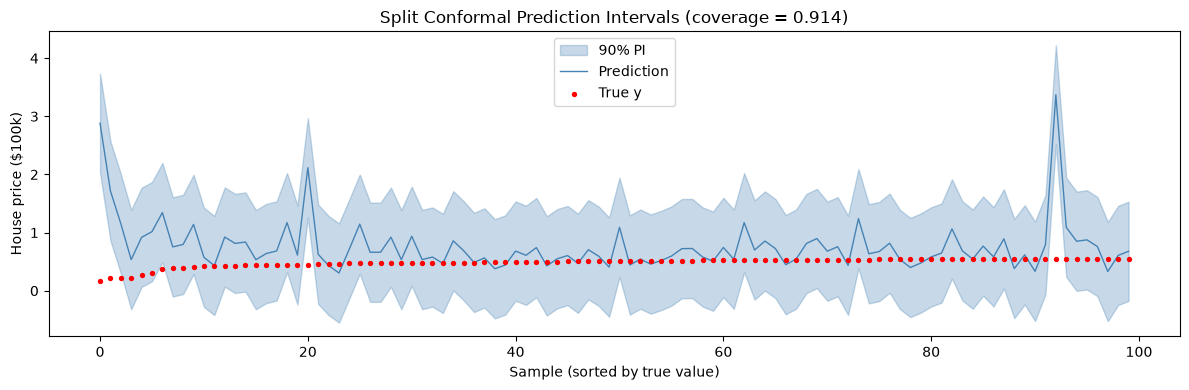

In [4]:
# Visualise prediction intervals on a sample
idx = np.argsort(y_te)[:100]
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(100), lower[idx], upper[idx], alpha=0.3, color='steelblue', label='90% PI')
ax.plot(range(100), point[idx], color='steelblue', lw=1, label='Prediction')
ax.scatter(range(100), y_te[idx], s=8, color='red', zorder=3, label='True y')
ax.set_xlabel('Sample (sorted by true value)')
ax.set_ylabel('House price ($100k)')
ax.set_title(f'Split Conformal Prediction Intervals (coverage = {coverage:.3f})')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Checking Coverage Across Alpha Levels

A key property: conformal intervals are valid for **any** target confidence level. We can sweep α and verify the guarantee.

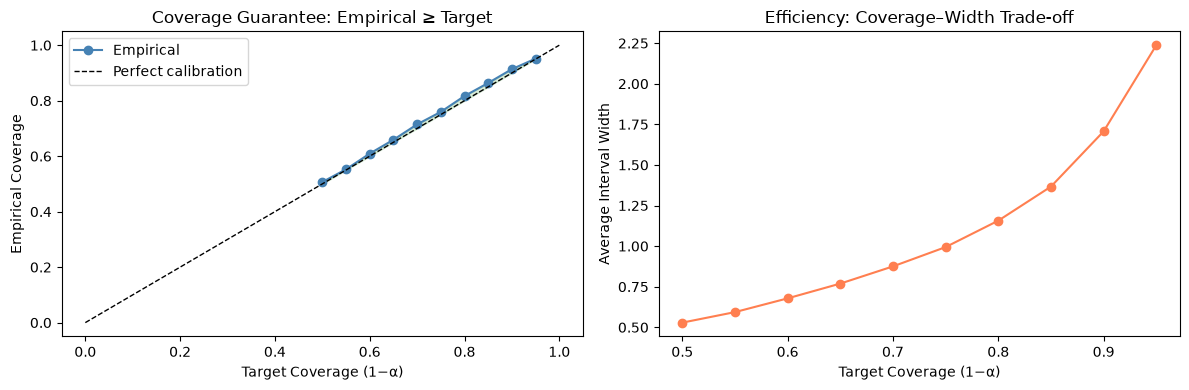

In [5]:
alphas = np.arange(0.05, 0.55, 0.05)
coverages, widths = [], []

for alpha in alphas:
    cp = ManualSplitCP(GradientBoostingRegressor(n_estimators=100, random_state=42), alpha=alpha)
    cp.fit(X_tr, y_tr)
    cp.calibrate(X_cal, y_cal)
    pt, lo, hi = cp.predict(X_te)
    coverages.append(np.mean((y_te >= lo) & (y_te <= hi)))
    widths.append(np.mean(hi - lo))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(1 - alphas, coverages, 'o-', color='steelblue', label='Empirical')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
axes[0].fill_between(1-alphas, 1-alphas, coverages, alpha=0.15, color='green')
axes[0].set_xlabel('Target Coverage (1−α)'); axes[0].set_ylabel('Empirical Coverage')
axes[0].set_title('Coverage Guarantee: Empirical ≥ Target'); axes[0].legend()

axes[1].plot(1 - alphas, widths, 'o-', color='coral')
axes[1].set_xlabel('Target Coverage (1−α)'); axes[1].set_ylabel('Average Interval Width')
axes[1].set_title('Efficiency: Coverage–Width Trade-off')

plt.tight_layout(); plt.show()

## 4. Adaptive Intervals via Normalised Conformal

The basic method produces constant-width intervals — uninformative near easy samples and too narrow near hard ones. **Normalised conformal** fixes this:

$$
s_i = \frac{|y_i - \hat{f}(x_i)|}{\hat{\sigma}(x_i)}
$$

where $\hat{\sigma}(x_i)$ is a difficulty estimator (e.g., absolute residuals from a secondary model).
The prediction interval then scales with local uncertainty: $\hat{f}(x) \pm \hat{q} \cdot \hat{\sigma}(x)$.

Normalised CP  — Coverage: 0.9070, Avg width: 1.4770
Standard CP    — Coverage: 0.9138, Avg width: 1.7068


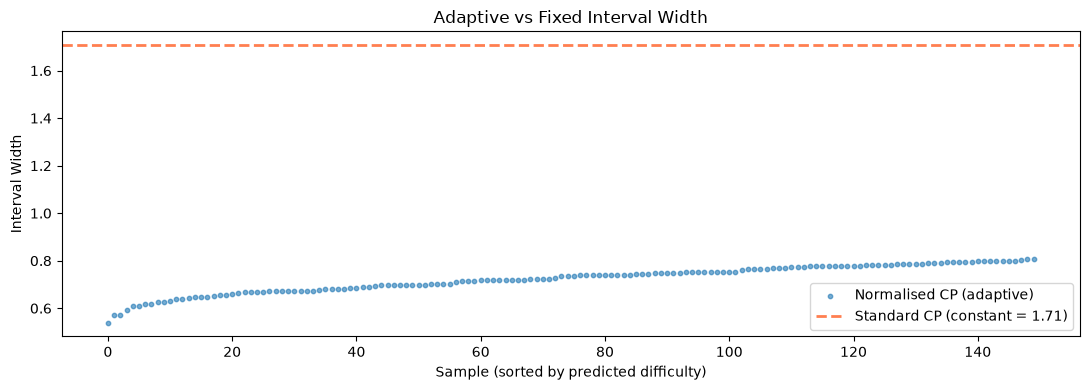

In [6]:
class NormalisedCP:
    """Normalised (difficulty-weighted) conformal regression."""
    def __init__(self, base_model, difficulty_model, alpha=0.1):
        self.model = base_model
        self.diff_model = difficulty_model
        self.alpha = alpha

    def fit(self, X, y):
        self.model.fit(X, y)
        residuals = np.abs(y - self.model.predict(X))
        self.diff_model.fit(X, residuals)
        return self

    def calibrate(self, X_cal, y_cal):
        residuals = np.abs(y_cal - self.model.predict(X_cal))
        sigma = np.maximum(self.diff_model.predict(X_cal), 1e-6)
        scores = residuals / sigma
        n = len(scores)
        level = np.ceil((1 - self.alpha) * (n + 1)) / n
        self.q_hat = np.quantile(scores, min(level, 1.0))
        return self

    def predict(self, X):
        pt = self.model.predict(X)
        sigma = np.maximum(self.diff_model.predict(X), 1e-6)
        margin = self.q_hat * sigma
        return pt, pt - margin, pt + margin, sigma


norm_cp = NormalisedCP(
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    GradientBoostingRegressor(n_estimators=50, random_state=0)
)
norm_cp.fit(X_tr, y_tr)
norm_cp.calibrate(X_cal, y_cal)
pt_n, lo_n, hi_n, sigma_n = norm_cp.predict(X_te)

cov_n = np.mean((y_te >= lo_n) & (y_te <= hi_n))
width_n = np.mean(hi_n - lo_n)
print(f'Normalised CP  — Coverage: {cov_n:.4f}, Avg width: {width_n:.4f}')
print(f'Standard CP    — Coverage: {coverage:.4f}, Avg width: {avg_width:.4f}')

idx = np.argsort(sigma_n)[:150]
fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(range(150), hi_n[idx] - lo_n[idx], s=10, alpha=0.6, label='Normalised CP (adaptive)')
ax.axhline(avg_width, color='coral', lw=2, ls='--', label=f'Standard CP (constant = {avg_width:.2f})')
ax.set_xlabel('Sample (sorted by predicted difficulty)')
ax.set_ylabel('Interval Width')
ax.set_title('Adaptive vs Fixed Interval Width')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Conformal Classification — Adaptive Prediction Sets

In [7]:
# Classification: predict SETS of labels with guaranteed coverage
iris = load_iris()
Xc, yc = iris.data.astype(np.float32), iris.target

# Stratified split to ensure all classes in train, cal, test
Xc_tr, Xc_tmp, yc_tr, yc_tmp = train_test_split(Xc, yc, test_size=0.5, stratify=yc, random_state=42)
Xc_cal, Xc_te, yc_cal, yc_te = train_test_split(Xc_tmp, yc_tmp, test_size=0.5, stratify=yc_tmp, random_state=42)

cls_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
cls_model.fit(Xc_tr, yc_tr)


class APSClassifier:
    """Adaptive Prediction Sets (APS): cumulative softmax-sorted score."""
    def __init__(self, model, alpha=0.1):
        self.model = model
        self.alpha = alpha

    def _nonconformity_score(self, probs, labels):
        scores = []
        for prob, y in zip(probs, labels):
            sorted_idx = np.argsort(prob)[::-1]
            cumsum = 0.0
            for idx in sorted_idx:
                cumsum += prob[idx]
                if idx == y:
                    scores.append(cumsum)
                    break
        return np.array(scores)

    def calibrate(self, X_cal, y_cal):
        probs = self.model.predict_proba(X_cal)
        scores = self._nonconformity_score(probs, y_cal)
        n = len(scores)
        level = np.ceil((1 - self.alpha) * (n + 1)) / n
        self.q_hat = np.quantile(scores, min(level, 1.0))
        return self

    def predict_set(self, X):
        probs = self.model.predict_proba(X)
        pred_sets = []
        for prob in probs:
            sorted_idx = np.argsort(prob)[::-1]
            cumsum, pred_set = 0.0, []
            for idx in sorted_idx:
                cumsum += prob[idx]
                pred_set.append(idx)
                if cumsum >= self.q_hat:
                    break
            pred_sets.append(sorted(pred_set))
        return pred_sets


aps = APSClassifier(cls_model, alpha=0.1)
aps.calibrate(Xc_cal, yc_cal)
pred_sets = aps.predict_set(Xc_te)

cov_cls = np.mean([yc_te[i] in s for i, s in enumerate(pred_sets)])
avg_set_size = np.mean([len(s) for s in pred_sets])

print(f'APS Classification — Coverage: {cov_cls:.4f} (target ≥ 0.90)')
print(f'Average prediction set size: {avg_set_size:.2f} (out of 3 classes)')
print(f'q̂ = {aps.q_hat:.4f}')
print('\nFirst 10 prediction sets:')
for i in range(10):
    names = [iris.target_names[j] for j in pred_sets[i]]
    true = iris.target_names[yc_te[i]]
    print(f'  True: {true:15s}  Set: {names}')

APS Classification — Coverage: 1.0000 (target ≥ 0.90)
Average prediction set size: 2.11 (out of 3 classes)
q̂ = 1.0000

First 10 prediction sets:
  True: versicolor       Set: [np.str_('versicolor'), np.str_('virginica')]
  True: versicolor       Set: [np.str_('versicolor'), np.str_('virginica')]
  True: virginica        Set: [np.str_('versicolor'), np.str_('virginica')]
  True: setosa           Set: [np.str_('setosa'), np.str_('versicolor')]
  True: setosa           Set: [np.str_('setosa'), np.str_('versicolor')]
  True: virginica        Set: [np.str_('versicolor'), np.str_('virginica')]
  True: versicolor       Set: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  True: virginica        Set: [np.str_('versicolor'), np.str_('virginica')]
  True: virginica        Set: [np.str_('virginica')]
  True: setosa           Set: [np.str_('setosa'), np.str_('versicolor')]


## 6. Using MAPIE (Production-Ready)

MAPIE 1.4.x uses a `fit` → `conformalize` → `predict_interval/predict_set` API.
With `prefit=False`, MAPIE trains the model internally during `fit`.

In [8]:
# MAPIE regression — SplitConformalRegressor
# prefit=False: trains the estimator inside fit(), then conformalize() sets the threshold
mapie_reg = MapieSCReg(
    estimator=GradientBoostingRegressor(n_estimators=100, random_state=42),
    confidence_level=0.9,
    prefit=False
)
mapie_reg.fit(X_tr, y_tr)
mapie_reg.conformalize(X_cal, y_cal)

# predict_interval returns (y_pred, y_pis) where y_pis.shape = (n, 2, 1)
mapie_pt, mapie_pi = mapie_reg.predict_interval(X_te)
mapie_lo, mapie_hi = mapie_pi[:, 0, 0], mapie_pi[:, 1, 0]

mapie_cov = np.mean((y_te >= mapie_lo) & (y_te <= mapie_hi))
print(f'MAPIE coverage: {mapie_cov:.4f}  (target 0.90)')
print(f'MAPIE avg width: {np.mean(mapie_hi - mapie_lo):.4f}')

MAPIE coverage: 0.9135  (target 0.90)
MAPIE avg width: 1.7066


In [9]:
# MAPIE classification — SplitConformalClassifier
# predict_set returns (y_pred, y_sets) where y_sets.shape = (n, n_classes, 1)
mapie_cls = MapieSCCls(
    estimator=GradientBoostingClassifier(n_estimators=100, random_state=42),
    confidence_level=0.9,
    prefit=False
)
mapie_cls.fit(Xc_tr, yc_tr)
mapie_cls.conformalize(Xc_cal, yc_cal)

_, mapie_sets = mapie_cls.predict_set(Xc_te)

mapie_cov_cls = np.mean([
    yc_te[i] in np.where(mapie_sets[i, :, 0])[0]
    for i in range(len(yc_te))
])
mapie_set_size = np.mean([mapie_sets[i, :, 0].sum() for i in range(len(yc_te))])
print(f'MAPIE classification coverage: {mapie_cov_cls:.4f}')
print(f'MAPIE average set size: {mapie_set_size:.2f} (out of 3)')

MAPIE classification coverage: 1.0000
MAPIE average set size: 1.13 (out of 3)


## 7. Conformal vs Bayesian Uncertainty

| Property | Conformal Prediction | Bayesian (e.g. GP, MC Dropout) |
|----------|---------------------|-------------------------------|
| **Coverage guarantee** | Yes — marginal, finite-sample | Only asymptotic (under model assumptions) |
| **Assumptions** | Exchangeability only | Full probabilistic model |
| **Model-agnostic** | Yes — any black box | No — model must support posterior |
| **Computational cost** | Low — calibration is one pass | High — MCMC or variational |
| **Interval type** | Marginal (averaged over X) | Conditional (depends on X) |
| **Adaptive to X** | Only with normalised scores | Yes — naturally |

**Key limitation of conformal**: marginal coverage means 90% of samples are covered, but a specific hard-to-predict region could have lower coverage. Conditional conformal (covariate-conditional) is an active research area.

## 8. Real-World Applications

- **Drug discovery**: prediction sets over molecule properties — exclude candidates whose true activity *could* be outside safe range
- **Fraud detection**: classify transactions as {fraud, benign, uncertain} — escalate uncertain cases to human review
- **Forecasting**: conformal prediction intervals for time series (requires a block-exchangeability variant)
- **LLM outputs**: conformal risk control for text generation quality metrics

## Additional Learning Resources

| Resource | Link | What It Covers |
|----------|------|----------------|
| **Gentle Introduction to Conformal Prediction** (Angelopoulos & Bates) | [arXiv:2107.07511](https://arxiv.org/abs/2107.07511) | Best tutorial; highly readable |
| **MAPIE documentation** | [mapie.readthedocs.io](https://mapie.readthedocs.io) | Regression, classification, time series |
| **APS (Adaptive Prediction Sets)** (Romano et al. 2020) | [arXiv:2006.02561](https://arxiv.org/abs/2006.02561) | RAPS and APS for classification |
| **Conformal Risk Control** (Angelopoulos et al. 2022) | [arXiv:2208.02814](https://arxiv.org/abs/2208.02814) | Extends to general risk functions |
| **CREPES library** | [github.com/henrikbostrom/crepes](https://github.com/henrikbostrom/crepes) | Normalised conformal regressors |
| **Conformal Prediction for LLMs** | [arXiv:2402.19474](https://arxiv.org/abs/2402.19474) | Token-level uncertainty for text generation |